In [437]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Acces Data dan EDA

In [438]:
df = pd.read_csv('../0.Dataset/titanic_kotor_1000.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,193,1,2,"Johnson, Mr./Mrs. Laina",female,NaN,2,0,PC 61897,14.6663,E46,S
1,540,0,3,"Futrelle, Mr./Mrs. Elizabeth",female,NaN,0,0,PC 45221,241.1648,NaN,S
2,122,1,3,"Allen, Mr./Mrs. Gosta",male,1.0,0,0,309144,7.7993,NaN,S
3,810,0,1,"Johnson, Mr./Mrs. Florence",female,8.0,1,0,PC 32983,18.6753,NaN,S
4,326,1,2,"Smith, Mr./Mrs. Laina",MALE,13.0,0,1,PC 22255,39.5465,NaN,Q


In [439]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1020 non-null   int64  
 1   Survived     1020 non-null   int64  
 2   Pclass       1020 non-null   int64  
 3   Name         1020 non-null   object 
 4   Sex          1020 non-null   object 
 5   Age          867 non-null    float64
 6   SibSp        1020 non-null   int64  
 7   Parch        1020 non-null   int64  
 8   Ticket       1020 non-null   object 
 9   Fare         1020 non-null   object 
 10  Cabin        258 non-null    object 
 11  Embarked     1000 non-null   object 
dtypes: float64(1), int64(5), object(6)
memory usage: 95.8+ KB


In [440]:
df.shape

(1020, 12)

In [441]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            153
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          762
Embarked        20
dtype: int64

In [442]:
df.duplicated().sum()

np.int64(20)

In [443]:
df = df.drop(columns=['PassengerId','Ticket'])
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,2,"Johnson, Mr./Mrs. Laina",female,NaN,2,0,14.6663,E46,S
1,0,3,"Futrelle, Mr./Mrs. Elizabeth",female,NaN,0,0,241.1648,NaN,S
2,1,3,"Allen, Mr./Mrs. Gosta",male,1.0,0,0,7.7993,NaN,S
3,0,1,"Johnson, Mr./Mrs. Florence",female,8.0,1,0,18.6753,NaN,S
4,1,2,"Smith, Mr./Mrs. Laina",MALE,13.0,0,1,39.5465,NaN,Q
...,...,...,...,...,...,...,...,...,...,...
1015,1,3,"Johnson, Mr./Mrs. Laina",male,62.0,0,0,90.6072,B145,S
1016,0,3,"McCarthy, Mr./Mrs. Florence",female,40.0,0,1,10.815,NaN,S
1017,0,3,"Heikkinen, Mr./Mrs. Florence",female,17.0,0,0,39.084,NaN,S
1018,0,1,"Cumings, Mr./Mrs. Owen",MALE,6.0,0,0,8.3612,NaN,s


## Impute Missing Value

In [444]:
colum_categorical = ['Survived','Pclass','Sex','SibSp','Parch','Cabin','Embarked']
for col in df[colum_categorical].columns:
    print(f"Nilai Unik di Kolom {col}")
    print(df[col].unique())
    print("-"*30)

Nilai Unik di Kolom Survived
[1 0]
------------------------------
Nilai Unik di Kolom Pclass
[2 3 1]
------------------------------
Nilai Unik di Kolom Sex
['female' 'male' 'MALE' 'FEMALE' 'mAlE']
------------------------------
Nilai Unik di Kolom SibSp
[2 0 1 4 3 5]
------------------------------
Nilai Unik di Kolom Parch
[0 1 2 5 4 3]
------------------------------
Nilai Unik di Kolom Cabin
['E46' nan 'B17' 'F37' 'C2' 'A11' 'B97' 'A83' 'F8' 'B43' 'C105' 'C143'
 'F83' 'C129' 'A120' 'A73' 'B134' 'C35' 'A111' 'B147' 'F111' 'B53' 'F147'
 'A75' 'D61' 'B16' 'D135' 'A66' 'D31' 'C106' 'F26' 'B42' 'B30' 'C60' 'E72'
 'C110' 'A79' 'E99' 'F148' 'C4' 'E43' 'B124' 'F65' 'A34' 'E103' 'D148'
 'F30' 'E10' 'E69' 'B150' 'F13' 'F88' 'F3' 'F106' 'B6' 'E74' 'E76' 'B75'
 'E71' 'E141' 'B25' 'D41' 'E88' 'F39' 'F6' 'F71' 'C83' 'C101' 'E59' 'A19'
 'E109' 'B71' 'E108' 'E54' 'B74' 'B24' 'A106' 'A144' 'B141' 'F2' 'D32'
 'F131' 'A71' 'C36' 'E26' 'A2' 'D58' 'D121' 'C54' 'B148' 'F57' 'D27'
 'D115' 'C59' 'B21' 'F114'

In [445]:
df['Sex'] = df['Sex'].str.upper()
df['Sex'].unique()

array(['FEMALE', 'MALE'], dtype=object)

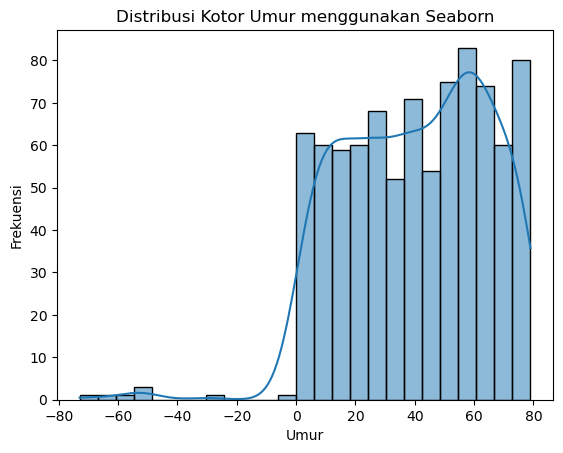

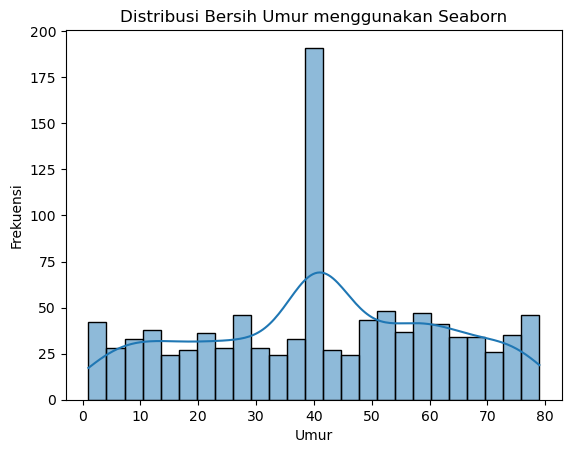

In [446]:
sns.histplot(data=df,x='Age',bins=25,kde=True)
plt.title('Distribusi Kotor Umur menggunakan Seaborn')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

df['Age'] = df['Age'].abs()
df['Age'] = df['Age'].fillna(df['Age'].mean().round())
df['Age'] = df['Age'].astype('int64')

sns.histplot(data=df,x='Age',bins=25,kde=True)
plt.title('Distribusi Bersih Umur menggunakan Seaborn')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

In [447]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       762
Embarked     20
dtype: int64

In [448]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])
df['Cabin'].isnull().sum()


np.int64(0)

In [449]:
df['Embarked'] = df['Embarked'].str.upper()
kamus_pelabuhan = {
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown'
}
df['Embarked'] = df['Embarked'].replace(kamus_pelabuhan)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isnull().sum()

np.int64(0)

In [450]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64

In [451]:
df['Embarked'].unique()

array(['Southampton', 'Queenstown', 'Cherbourg'], dtype=object)

In [452]:
if df['Fare'].dtype == 'object':
    filter_alfabet = df[df['Fare'].str.contains(r'^[a-zA-Z\s]+$', na=False)]
    nilai_unik_huruf = filter_alfabet['Fare'].unique()
    print(f"Nilai unik berupa huruf yang ditemukan: {nilai_unik_huruf}\n")
    
    kamus_Fare = {
        'FREE': '0',
        'hundred dollars': '100'  
    }
    
    df['Fare'] = df['Fare'].replace(kamus_Fare)
    df['Fare'] = df['Fare'].astype('float64')
    print("=== PROSES SELESAI: Kolom 'Fare' berhasil diubah ke float64 ===\n")

else:
    print(f"=== INFO: Kolom 'Fare' sudah bertipe {df['Fare'].dtype}, tidak perlu dibersihkan lagi. ===\n")

Nilai unik berupa huruf yang ditemukan: ['FREE' 'hundred dollars']

=== PROSES SELESAI: Kolom 'Fare' berhasil diubah ke float64 ===



## FIltering Outliers

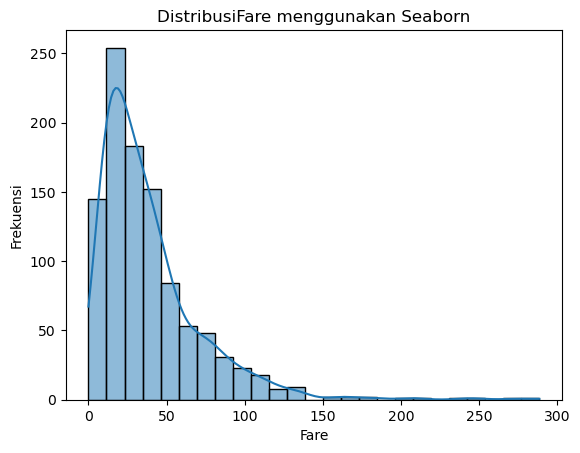

In [453]:
sns.histplot(data=df,x='Fare',bins=25,kde=True)
plt.title('DistribusiFare menggunakan Seaborn')
plt.xlabel('Fare')
plt.ylabel('Frekuensi')
plt.show()

